# PSet 3 - Problem 2 (AR1 continuum, stable MATLAB-aligned implementation)

This notebook extends the stable Problem 1 v2 structure to continuous AR1 idiosyncratic income with Gaussian quadrature.

Implemented:
1. Grid VFI benchmark
2. Coefficient VFI (tensor-product cubic spline collocation)
3. Howard improvement
4. Ergodic distribution via quadrature-based transition matrix
5. Problem-set diagnostics (policies, MPC, Euler checks, aggregates, comparison figures)

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.sparse import linalg as spla
from scipy.interpolate import RegularGridInterpolator

# Allow running this notebook without installing hetmacro system-wide.
REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from hetmacro.interpolation import (
    cubic_basis_matrix,
    linear_basis_matrix,
    tensor_basis_matrix,
    greville_abscissae,
)
from hetmacro.optimize import golden_max_vec
from hetmacro.forward import stationary_eigenvector
from hetmacro.quadrature import qnwnorm

# Directory for figure exports (slides)
TEX_DIR = REPO_ROOT / "examples" / "pset3" / "tex"
TEX_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
class AR1IncomeModel:
    def __init__(
        self,
        beta=0.95,
        gamma=1.5,
        r=0.02,
        rho=0.90,
        sigma_eps=0.20,
        amin=0.0,
        amax=50.0,
        n_a_breaks=51,
        n_z_breaks=15,
        n_quad=7,
        c_floor=1e-8,
        policy_tol=1e-6,
        max_iter=300,
        tol=1e-6,
    ):
        self.beta = float(beta)
        self.gamma = float(gamma)
        self.r = float(r)
        self.rho = float(rho)
        self.sigma_eps = float(sigma_eps)
        self.amin = float(amin)
        self.amax = float(amax)
        self.n_a_breaks = int(n_a_breaks)
        self.n_z_breaks = int(n_z_breaks)
        self.n_quad = int(n_quad)
        self.c_floor = float(c_floor)
        self.policy_tol = float(policy_tol)
        self.max_iter = int(max_iter)
        self.tol = float(tol)

        # MATLAB-style breakpoints
        ua = np.linspace(0.0, 1.0, self.n_a_breaks)
        self.a_breaks = self.amin + (self.amax - self.amin) * ua**2

        self.z_std = self.sigma_eps / np.sqrt(1.0 - self.rho**2)
        self.zmin = -4.0 * self.z_std
        self.zmax = 4.0 * self.z_std
        self.z_breaks = np.linspace(self.zmin, self.zmax, self.n_z_breaks)

        # Greville collocation nodes (CompEcon-style)
        self.a_nodes = greville_abscissae(self.a_breaks, degree=3)
        self.z_nodes = greville_abscissae(self.z_breaks, degree=3)
        self.n_a_nodes = self.a_nodes.size
        self.n_z_nodes = self.z_nodes.size

        # Tensor collocation states in row-major: z runs fastest (MATLAB-like flattening)
        self.A_nodes = np.repeat(self.a_nodes, self.n_z_nodes)
        self.Z_nodes = np.tile(self.z_nodes, self.n_a_nodes)
        self.n_states = self.A_nodes.size

        # tensor_basis_matrix builds columns in a-fast ordering (kron(z, a)).
        # Keep explicit permutations to map between:
        #   z-fast index: idx_z = ia * n_z + iz  (MATLAB/gridmake convention)
        #   a-fast index: idx_a = iz * n_a + ia  (tensor kron(z, a) convention)
        self._perm_z_to_a = np.arange(self.n_states).reshape(self.n_a_nodes, self.n_z_nodes, order="C").ravel(order="F")
        self._perm_a_to_z = np.argsort(self._perm_z_to_a)

        self.Phi_a_nodes = cubic_basis_matrix(self.a_breaks, self.A_nodes)
        self.Phi_z_nodes = cubic_basis_matrix(self.z_breaks, self.Z_nodes)
        self.Phi = tensor_basis_matrix(self.Phi_a_nodes, self.Phi_z_nodes).tocsr()
        self._phi_solver = spla.factorized(self.Phi.tocsc())

        # Gaussian quadrature for eps ~ N(0, sigma_eps^2)
        self.eps_nodes, self.eps_w = qnwnorm(self.n_quad, mu=0.0, sigma=self.sigma_eps)

        self._z_basis_cache = [
            cubic_basis_matrix(self.z_breaks, self._clamp_z(self.rho * self.Z_nodes + eps)).toarray()
            for eps in self.eps_nodes
        ]

    def _resources(self, a, z):
        return np.exp(z) + (1.0 + self.r) * a

    def _u(self, c):
        c = np.maximum(np.asarray(c), self.c_floor)
        if abs(self.gamma - 1.0) < 1e-12:
            return np.log(c)
        return c ** (1.0 - self.gamma) / (1.0 - self.gamma)

    def _clamp_a(self, x):
        return np.clip(x, self.amin, self.amax)

    def _clamp_z(self, z):
        return np.clip(z, self.zmin, self.zmax)

    def _theta_to_mat(self, theta):
        # Value-function coefficients live in tensor_basis_matrix column order (a-fast).
        # With shape (n_a_nodes, n_z_nodes), this is Fortran-order reshape.
        return np.asarray(theta).reshape(self.n_a_nodes, self.n_z_nodes, order="F")

    def _expected_continuation_at_nodes(self, a_prime, theta_mat):
        a_prime = self._clamp_a(a_prime)
        B_a = cubic_basis_matrix(self.a_breaks, a_prime).toarray()
        BATheta = B_a @ theta_mat
        out = np.zeros_like(a_prime)
        for w, B_z in zip(self.eps_w, self._z_basis_cache):
            out += w * np.sum(BATheta * B_z, axis=1)
        return out

    def _objective_nodes(self, a_prime, m, theta_mat):
        a_prime = self._clamp_a(a_prime)
        c = np.maximum(m - a_prime, self.c_floor)
        cont = self._expected_continuation_at_nodes(a_prime, theta_mat)
        return self._u(c) + self.beta * cont

    def policy_improvement_nodes(self, theta, tol=None):
        if tol is None:
            tol = self.policy_tol
        theta_mat = self._theta_to_mat(theta)

        m = self._resources(self.A_nodes, self.Z_nodes)
        lo = np.full(self.n_states, self.amin)
        hi = self._clamp_a(m - self.c_floor)
        hi = np.maximum(hi, lo + 1e-12)

        def obj(x):
            return self._objective_nodes(x, m, theta_mat)

        a_pol, v_nodes = golden_max_vec(obj, lo, hi, tol=tol)
        c_pol = np.maximum(m - a_pol, self.c_floor)
        return a_pol, c_pol, v_nodes

    def vfi_step_coeff(self, theta, policy_tol=None):
        a_pol, c_pol, v_nodes = self.policy_improvement_nodes(theta, tol=policy_tol)
        theta_new = self._phi_solver(v_nodes)
        err = float(np.max(np.abs(theta_new - theta)))
        return {
            "theta": theta_new,
            "a_pol": a_pol,
            "c_pol": c_pol,
            "v_nodes": v_nodes,
            "err": err,
        }

    def solve_vfi_coeff(self, max_iter=None, tol=None, policy_tol=None, relax=1.0, verbose=True):
        if max_iter is None:
            max_iter = self.max_iter
        if tol is None:
            tol = self.tol

        theta = np.zeros(self.n_states)
        out = None
        for it in range(1, max_iter + 1):
            theta_old = theta.copy()
            out = self.vfi_step_coeff(theta_old, policy_tol=policy_tol)
            theta_candidate = out["theta"]
            theta = (1.0 - relax) * theta_old + relax * theta_candidate
            out["theta"] = theta
            out["err"] = float(np.max(np.abs(theta - theta_old)))

            if verbose and (it <= 10 or it % 20 == 0):
                print(f"Coeff VFI iter {it:4d} | err = {out['err']:.3e}")
            if out["err"] < tol:
                if verbose:
                    print(f"Coeff VFI converged at iter {it} (err={out['err']:.3e})")
                break
        else:
            if verbose:
                print(f"Coeff VFI reached max_iter={max_iter} with err={out['err']:.3e}")

        out["iter"] = it
        out["converged"] = out["err"] < tol
        out["relax"] = relax
        return out

    def howard_policy_evaluation(self, a_pol):
        a_pol = self._clamp_a(a_pol)
        m = self._resources(self.A_nodes, self.Z_nodes)
        c_pol = np.maximum(m - a_pol, self.c_floor)
        u_pol = self._u(c_pol)

        vtheta = sparse.csr_matrix((self.n_states, self.n_states))
        Phi_a_next = cubic_basis_matrix(self.a_breaks, a_pol)
        for eps, w in zip(self.eps_nodes, self.eps_w):
            z_next = self._clamp_z(self.rho * self.Z_nodes + eps)
            Phi_z_next = cubic_basis_matrix(self.z_breaks, z_next)
            Phi_next = tensor_basis_matrix(Phi_a_next, Phi_z_next).tocsr()
            vtheta = vtheta + self.beta * w * Phi_next

        lhs = self.Phi - vtheta
        theta_new = spla.spsolve(lhs.tocsc(), u_pol)
        return theta_new, c_pol

    def solve_howard(self, n_warmup=2, max_iter=120, tol=1e-6, policy_tol=None, verbose=True):
        theta = np.zeros(self.n_states)
        for _ in range(n_warmup):
            tmp = self.vfi_step_coeff(theta, policy_tol=policy_tol)
            theta = tmp["theta"]

        out = None
        for it in range(1, max_iter + 1):
            a_pol, c_pol, _ = self.policy_improvement_nodes(theta, tol=policy_tol)
            theta_new, c_eval = self.howard_policy_evaluation(a_pol)
            err = float(np.max(np.abs(theta_new - theta)))
            theta = theta_new

            out = {
                "theta": theta,
                "a_pol": a_pol,
                "c_pol": c_eval,
                "err": err,
            }
            if verbose and (it <= 10 or it % 10 == 0):
                print(f"Howard iter {it:4d} | err = {err:.3e}")
            if err < tol:
                if verbose:
                    print(f"Howard converged at iter {it} (err={err:.3e})")
                break
        else:
            if verbose:
                print(f"Howard reached max_iter={max_iter} with err={out['err']:.3e}")

        out["iter"] = it
        out["converged"] = out["err"] < tol
        return out

    def solve_vfi_grid(self, n_a=81, n_z=25, a_grid=None, z_grid=None, max_iter=500, tol=1e-6, policy_tol=1e-5, verbose=True):
        if a_grid is None:
            ua = np.linspace(0.0, 1.0, n_a)
            a_grid = self.amin + (self.amax - self.amin) * ua**2
        else:
            a_grid = np.asarray(a_grid, dtype=float)
            n_a = a_grid.size

        if z_grid is None:
            z_grid = np.linspace(self.zmin, self.zmax, n_z)
        else:
            z_grid = np.asarray(z_grid, dtype=float)
            n_z = z_grid.size

        A = np.repeat(a_grid, n_z)
        Z = np.tile(z_grid, n_a)
        N = A.size

        V = np.zeros((n_a, n_z))
        a_pol = np.full((n_a, n_z), self.amin)

        for it in range(1, max_iter + 1):
            interp_V = RegularGridInterpolator((a_grid, z_grid), V, method="linear", bounds_error=False, fill_value=None)
            m = self._resources(A, Z)
            lo = np.full(N, self.amin)
            hi = self._clamp_a(m - self.c_floor)
            hi = np.maximum(hi, lo + 1e-12)

            def obj(x):
                x = self._clamp_a(x)
                c = np.maximum(m - x, self.c_floor)
                cont = np.zeros(N)
                for eps, w in zip(self.eps_nodes, self.eps_w):
                    z_next = self._clamp_z(self.rho * Z + eps)
                    pts = np.column_stack([x, z_next])
                    cont += w * interp_V(pts)
                return self._u(c) + self.beta * cont

            x_star, v_star = golden_max_vec(obj, lo, hi, tol=policy_tol)
            V_new = v_star.reshape(n_a, n_z)
            err = float(np.max(np.abs(V_new - V)))
            V = V_new
            a_pol = x_star.reshape(n_a, n_z)

            if verbose and (it <= 10 or it % 25 == 0):
                print(f"Grid VFI iter {it:4d} | err = {err:.3e}")
            if err < tol:
                if verbose:
                    print(f"Grid VFI converged at iter {it} (err={err:.3e})")
                break
        else:
            if verbose:
                print(f"Grid VFI reached max_iter={max_iter} with err={err:.3e}")

        c_pol = np.maximum(self._resources(a_pol.reshape(-1), np.tile(z_grid, n_a)) - a_pol.reshape(-1), self.c_floor).reshape(n_a, n_z)
        return {
            "a_grid": a_grid,
            "z_grid": z_grid,
            "V": V,
            "a_pol": a_pol,
            "c_pol": c_pol,
            "iter": it,
            "err": err,
            "converged": err < tol,
        }

    def values_from_theta(self, theta, a_eval, z_eval):
        Ba = cubic_basis_matrix(self.a_breaks, a_eval).toarray()
        Bz = cubic_basis_matrix(self.z_breaks, z_eval).toarray()
        T = self._theta_to_mat(theta)
        return Ba @ T @ Bz.T

    def policy_to_matrix(self, a_pol_flat):
        return np.asarray(a_pol_flat).reshape(self.n_a_nodes, self.n_z_nodes)

    def policy_interpolator(self, a_pol_flat):
        APol = self.policy_to_matrix(a_pol_flat)
        return RegularGridInterpolator(
            (self.a_nodes, self.z_nodes),
            APol,
            method="linear",
            bounds_error=False,
            fill_value=None,
        )

    def _policy_from_theta_on_points(self, A, Z, theta, policy_tol=None):
        if policy_tol is None:
            policy_tol = self.policy_tol
        theta_mat = self._theta_to_mat(theta)

        m = self._resources(A, Z)
        lo = np.full(A.size, self.amin)
        hi = self._clamp_a(m - self.c_floor)
        hi = np.maximum(hi, lo + 1e-12)

        def obj(x):
            x = self._clamp_a(x)
            c = np.maximum(m - x, self.c_floor)

            B_a = cubic_basis_matrix(self.a_breaks, x).toarray()
            BATheta = B_a @ theta_mat
            cont = np.zeros_like(x)
            for eps, w in zip(self.eps_nodes, self.eps_w):
                z_next = self._clamp_z(self.rho * Z + eps)
                B_z = cubic_basis_matrix(self.z_breaks, z_next).toarray()
                cont += w * np.sum(BATheta * B_z, axis=1)

            return self._u(c) + self.beta * cont

        a_pol, _ = golden_max_vec(obj, lo, hi, tol=policy_tol)
        return self._clamp_a(a_pol)

    def compute_ergodic(
        self,
        a_pol,
        ka=121,
        kz=41,
        policy_kind="spline_nodes",
        policy_a_grid=None,
        policy_z_grid=None,
        theta=None,
        policy_tol=None,
    ):
        a_fine = np.linspace(self.amin, self.amax, ka)
        z_fine = np.linspace(self.zmin, self.zmax, kz)
        A = np.repeat(a_fine, kz)
        Z = np.tile(z_fine, ka)
        N = A.size

        if policy_kind == "spline_nodes":
            pol_interp = self.policy_interpolator(a_pol)
            points = np.column_stack([A, Z])
            a_prime = self._clamp_a(pol_interp(points))
        elif policy_kind == "grid":
            if policy_a_grid is None or policy_z_grid is None:
                raise ValueError("policy_a_grid and policy_z_grid are required when policy_kind='grid'.")
            a_g = np.asarray(policy_a_grid, dtype=float)
            z_g = np.asarray(policy_z_grid, dtype=float)
            APol = np.asarray(a_pol, dtype=float)
            if APol.ndim == 1:
                if APol.size != a_g.size * z_g.size:
                    raise ValueError("Flat a_pol has incompatible size for provided policy grids.")
                APol = APol.reshape(a_g.size, z_g.size)
            elif APol.shape != (a_g.size, z_g.size):
                raise ValueError("a_pol shape must be (len(policy_a_grid), len(policy_z_grid)).")
            pol_interp = RegularGridInterpolator(
                (a_g, z_g),
                APol,
                method="linear",
                bounds_error=False,
                fill_value=None,
            )
            points = np.column_stack([A, Z])
            a_prime = self._clamp_a(pol_interp(points))
        elif policy_kind == "theta_opt":
            if theta is None:
                raise ValueError("theta must be provided when policy_kind='theta_opt'.")
            a_prime = self._policy_from_theta_on_points(A, Z, theta, policy_tol=policy_tol)
        else:
            raise ValueError("policy_kind must be one of {'spline_nodes', 'grid', 'theta_opt'}.")

        Q = sparse.csr_matrix((N, N))
        Phi_a = linear_basis_matrix(a_fine, a_prime)

        # Local permutation for this ergodic grid (ka, kz):
        # tensor_basis_matrix columns are a-fast (idx_a = iz*ka + ia),
        # while A/Z are z-fast (idx_z = ia*kz + iz, MATLAB/gridmake order).
        perm_z_to_a = np.arange(N).reshape(ka, kz, order="C").ravel(order="F")
        perm_a_to_z = np.argsort(perm_z_to_a)

        for eps, w in zip(self.eps_nodes, self.eps_w):
            z_prime = self._clamp_z(self.rho * Z + eps)
            Phi_z = linear_basis_matrix(z_fine, z_prime)
            B = tensor_basis_matrix(Phi_a, Phi_z).tocsr()
            B = B[:, perm_a_to_z]
            Q = Q + w * B

        n = stationary_eigenvector(Q)
        resid = float(np.linalg.norm(n - Q.T @ n))

        c = np.maximum(self._resources(A, Z) - a_prime, self.c_floor)
        n_a = n.reshape(ka, kz).sum(axis=1)

        moments = {
            "aggregate_assets": float(np.dot(n, A)),
            "aggregate_income": float(np.dot(n, np.exp(Z) + self.r * A)),
            "aggregate_consumption": float(np.dot(n, c)),
            "stationarity_residual": resid,
        }

        return {
            "policy_kind": policy_kind,
            "a_grid": a_fine,
            "z_grid": z_fine,
            "A": A,
            "Z": Z,
            "a_prime": a_prime,
            "c": c,
            "Q": Q,
            "n": n,
            "n_a": n_a,
            "moments": moments,
        }

    def euler_check(self, a_vals, z_val, a_pol_flat):
        pol_interp = self.policy_interpolator(a_pol_flat)
        z_arr = np.full_like(a_vals, float(z_val))
        pts = np.column_stack([a_vals, z_arr])
        a1 = self._clamp_a(pol_interp(pts))
        c1 = np.maximum(self._resources(a_vals, z_arr) - a1, self.c_floor)

        emu = np.zeros_like(a_vals)
        for eps, w in zip(self.eps_nodes, self.eps_w):
            z2 = self._clamp_z(self.rho * z_arr + eps)
            pts2 = np.column_stack([a1, z2])
            a2 = self._clamp_a(pol_interp(pts2))
            c2 = np.maximum(self._resources(a1, z2) - a2, self.c_floor)
            emu += w * c2 ** (-self.gamma)

        chat = (self.beta * (1.0 + self.r) * emu) ** (-1.0 / self.gamma)
        constrained = a1 <= (self.amin + 1e-10)
        chat[constrained] = c1[constrained]

        rel_err = (chat - c1) / c1
        return {
            "a": a_vals,
            "c": c1,
            "chat": chat,
            "rel_err": rel_err,
            "constrained": constrained,
        }

In [3]:
# Parameters and grid per ps3-1.pdf §2: β=0.95, r=0.02, ρ=0.90, σ=0.20, α=1.5, k=7,
# amax=50, a∈[0,50] with 51 breakpoints (clustered via u²), z ±4σ_z with 15 breakpoints.
# Full grid (no test mode).
m = AR1IncomeModel(
    beta=0.95,
    gamma=1.5,
    r=0.02,
    rho=0.90,
    sigma_eps=0.20,
    amin=0.0,
    amax=50.0,
    n_a_breaks=51,
    n_z_breaks=15,
    n_quad=7,
    c_floor=1e-8,
    policy_tol=1e-6,
    max_iter=300,
    tol=1e-6,
)

print(f"collocation nodes: n_a={m.n_a_nodes}, n_z={m.n_z_nodes}, total={m.n_states}")

collocation nodes: n_a=53, n_z=17, total=901


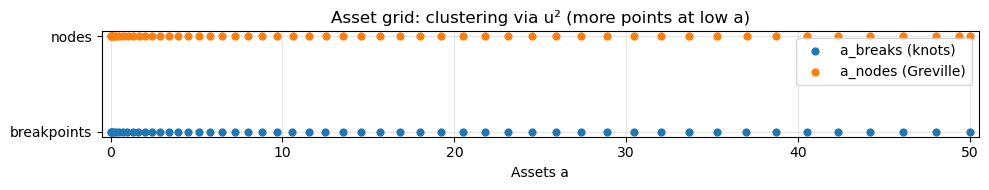

In [4]:
# Asset grid on the a-axis: breakpoints (spline knots) and collocation nodes (Greville)
fig, ax = plt.subplots(figsize=(10, 2))
ax.scatter(m.a_breaks, np.zeros_like(m.a_breaks), c="C0", s=24, label="a_breaks (knots)", zorder=2)
ax.scatter(m.a_nodes, np.ones_like(m.a_nodes), c="C1", s=24, label="a_nodes (Greville)", zorder=2)
ax.set_xlabel("Assets a")
ax.set_yticks([0, 1])
ax.set_yticklabels(["breakpoints", "nodes"])
ax.legend(loc="upper right")
ax.set_xlim(m.amin - 0.5, m.amax + 0.5)
ax.grid(True, alpha=0.3)
ax.set_title("Asset grid: clustering via u² (more points at low a)")
plt.tight_layout()
plt.show()

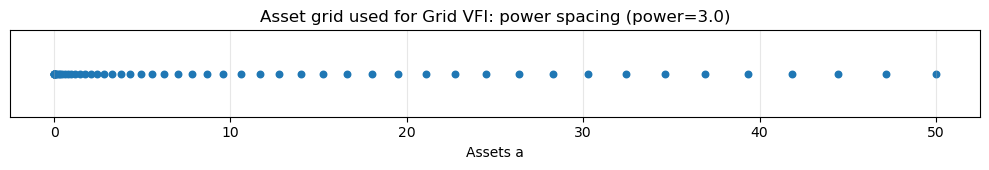

Grid VFI iter    1 | err = 5.007e+00
Grid VFI iter    2 | err = 4.314e+00
Grid VFI iter    3 | err = 3.780e+00
Grid VFI iter    4 | err = 3.346e+00
Grid VFI iter    5 | err = 2.984e+00
Grid VFI iter    6 | err = 2.680e+00
Grid VFI iter    7 | err = 2.420e+00
Grid VFI iter    8 | err = 2.196e+00
Grid VFI iter    9 | err = 2.002e+00
Grid VFI iter   10 | err = 1.832e+00
Grid VFI iter   25 | err = 6.457e-01
Grid VFI iter   50 | err = 1.660e-01
Grid VFI iter   75 | err = 4.565e-02
Grid VFI iter  100 | err = 1.264e-02
Grid VFI iter  125 | err = 3.507e-03
Grid VFI iter  150 | err = 9.727e-04
Grid VFI iter  175 | err = 2.698e-04
Grid VFI iter  200 | err = 7.484e-05
Grid VFI iter  225 | err = 2.076e-05
Grid VFI iter  250 | err = 5.759e-06
Grid VFI iter  275 | err = 1.597e-06
Grid VFI converged at iter 285 (err=9.564e-07)
Grid VFI time: 2.38 s


In [5]:
import time
from hetmacro.grids import make_grid_1d

# --- Grid VFI on an alternative asset grid (power spacing) ---
# Same bounds as ps3-1.pdf: a ∈ [amin, amax].
# Keep the same number of a-points as the collocation grid, but change spacing.
a_power = 3.0
ag_power = make_grid_1d(m.amin, m.amax, m.n_a_nodes, spacing="power", power=a_power)
zg_power = m.z_nodes

fig, ax = plt.subplots(figsize=(10, 1.8))
ax.scatter(ag_power, np.zeros_like(ag_power), s=22)
ax.set_title(f"Asset grid used for Grid VFI: power spacing (power={a_power})")
ax.set_xlabel("Assets a")
ax.set_yticks([])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

t0 = time.perf_counter()
res_grid = m.solve_vfi_grid(a_grid=ag_power, z_grid=zg_power, max_iter=300, tol=1e-6, policy_tol=2e-4, verbose=True)
t_grid = time.perf_counter() - t0
print(f"Grid VFI time: {t_grid:.2f} s")

In [6]:
# --- Coefficient VFI ---
t0 = time.perf_counter()
res_coeff = m.solve_vfi_coeff(max_iter=500, tol=1e-6, policy_tol=2e-4, relax=1.0, verbose=True)
if not res_coeff["converged"]:
    print("\nRetrying coefficient VFI with stable relaxation (relax=0.9)...")
    res_coeff = m.solve_vfi_coeff(max_iter=500, tol=1e-6, policy_tol=2e-4, relax=0.9, verbose=True)
t_coeff = time.perf_counter() - t0
print(f"Coefficient VFI time: {t_coeff:.2f} s")

Coeff VFI iter    1 | err = 5.007e+00
Coeff VFI iter    2 | err = 4.317e+00
Coeff VFI iter    3 | err = 3.779e+00
Coeff VFI iter    4 | err = 3.342e+00
Coeff VFI iter    5 | err = 2.978e+00
Coeff VFI iter    6 | err = 2.672e+00
Coeff VFI iter    7 | err = 2.411e+00
Coeff VFI iter    8 | err = 2.186e+00
Coeff VFI iter    9 | err = 1.992e+00
Coeff VFI iter   10 | err = 1.823e+00
Coeff VFI iter   20 | err = 8.733e-01
Coeff VFI iter   40 | err = 2.801e-01
Coeff VFI iter   60 | err = 9.871e-02
Coeff VFI iter   80 | err = 3.528e-02
Coeff VFI iter  100 | err = 1.264e-02
Coeff VFI iter  120 | err = 4.530e-03
Coeff VFI iter  140 | err = 1.624e-03
Coeff VFI iter  160 | err = 5.822e-04
Coeff VFI iter  180 | err = 2.087e-04
Coeff VFI iter  200 | err = 7.482e-05
Coeff VFI iter  220 | err = 2.682e-05
Coeff VFI iter  240 | err = 9.615e-06
Coeff VFI iter  260 | err = 3.447e-06
Coeff VFI iter  280 | err = 1.236e-06
Coeff VFI converged at iter 285 (err=9.561e-07)
Coefficient VFI time: 3.45 s


In [7]:
# --- Howard improvement ---
t0 = time.perf_counter()
res_howard = m.solve_howard(n_warmup=2, max_iter=100, tol=1e-6, policy_tol=2e-4, verbose=True)
t_howard = time.perf_counter() - t0
print(f"Howard time: {t_howard:.2f} s")

Howard iter    1 | err = 4.864e+01
Howard iter    2 | err = 7.564e+00
Howard iter    3 | err = 1.814e+00
Howard iter    4 | err = 6.973e-02
Howard iter    5 | err = 1.105e-04
Howard iter    6 | err = 2.266e-08
Howard converged at iter 6 (err=2.266e-08)
Howard time: 4.98 s


In [55]:
# --- Convergence summary (run after grid, coeff, and howard cells) ---
import pandas as pd

summary = pd.DataFrame({
    "method": ["grid", "coeff", "howard"],
    "iter": [res_grid["iter"], res_coeff["iter"], res_howard["iter"]],
    "err": [res_grid["err"], res_coeff["err"], res_howard["err"]],
    "converged": [res_grid["converged"], res_coeff["converged"], res_howard["converged"]],
    "relax": [None, res_coeff.get("relax", 1.0), None],
    "time_s": [round(t_grid, 2), round(t_coeff, 2), round(t_howard, 2)],
}).set_index("method")

print("Convergence summary")
print(summary)

Convergence summary
        iter           err  converged  relax  time_s
method                                              
grid     285  9.564449e-07       True    NaN    2.58
coeff    285  9.561066e-07       True    1.0   44.76
howard     6  2.266133e-08       True    NaN    7.97


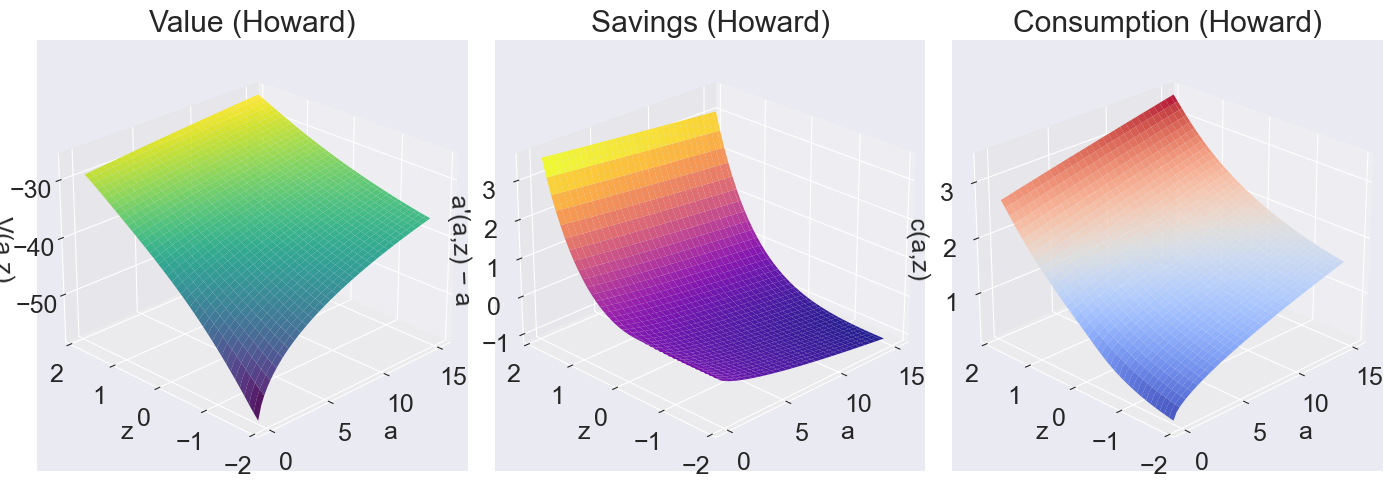

In [56]:
# Surface plots: value, savings (a'), and consumption from Howard
from mpl_toolkits.mplot3d import Axes3D

a_fine = np.linspace(m.amin, min(m.amax, 15.0), 60)
z_fine = np.linspace(m.zmin, m.zmax, 40)
Ag, Zg = np.meshgrid(a_fine, z_fine, indexing="ij")

# Value V(a,z)
Vh = m.values_from_theta(res_howard["theta"], a_fine, z_fine)

# Smooth policy/consumption via spline fit on the same tensor-product basis
# Fit coefficients θ_{a'} such that Φ(a_nodes,z_nodes) θ_{a'} = a'(a_nodes,z_nodes)
theta_ap = m._phi_solver(res_howard["a_pol"])
a_prime = m.values_from_theta(theta_ap, a_fine, z_fine)

# Enforce feasibility (spline evaluation can slightly overshoot)
m_res = m._resources(Ag, Zg)
a_hi = np.maximum(m.amin, m_res - m.c_floor)
a_prime = np.clip(a_prime, m.amin, m.amax)
a_prime = np.minimum(a_prime, a_hi)
Ch = np.maximum(m_res - a_prime, m.c_floor)

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(Ag, Zg, Vh, cmap="viridis", alpha=0.9, edgecolor="none")
ax1.set_xlabel("a")
ax1.set_ylabel("z")
ax1.set_zlabel("V(a,z)")
ax1.set_title("Value (Howard)")
ax1.view_init(elev=25, azim=225)

savings = a_prime - Ag
ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(Ag, Zg, savings, cmap="plasma", alpha=0.9, edgecolor="none")
ax2.set_xlabel("a")
ax2.set_ylabel("z")
ax2.set_zlabel("a'(a,z) − a")
ax2.set_title("Savings (Howard)")
ax2.view_init(elev=25, azim=225)

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(Ag, Zg, Ch, cmap="coolwarm", alpha=0.9, edgecolor="none")
ax3.set_xlabel("a")
ax3.set_ylabel("z")
ax3.set_zlabel("c(a,z)")
ax3.set_title("Consumption (Howard)")
ax3.view_init(elev=25, azim=225)

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_3d_surfaces.pdf", bbox_inches="tight", dpi=150)
plt.show()

Interior max abs differences vs Grid benchmark
Value:   coeff=2.187e-01, howard=2.187e-01
Savings: coeff=6.007e-02, howard=6.007e-02


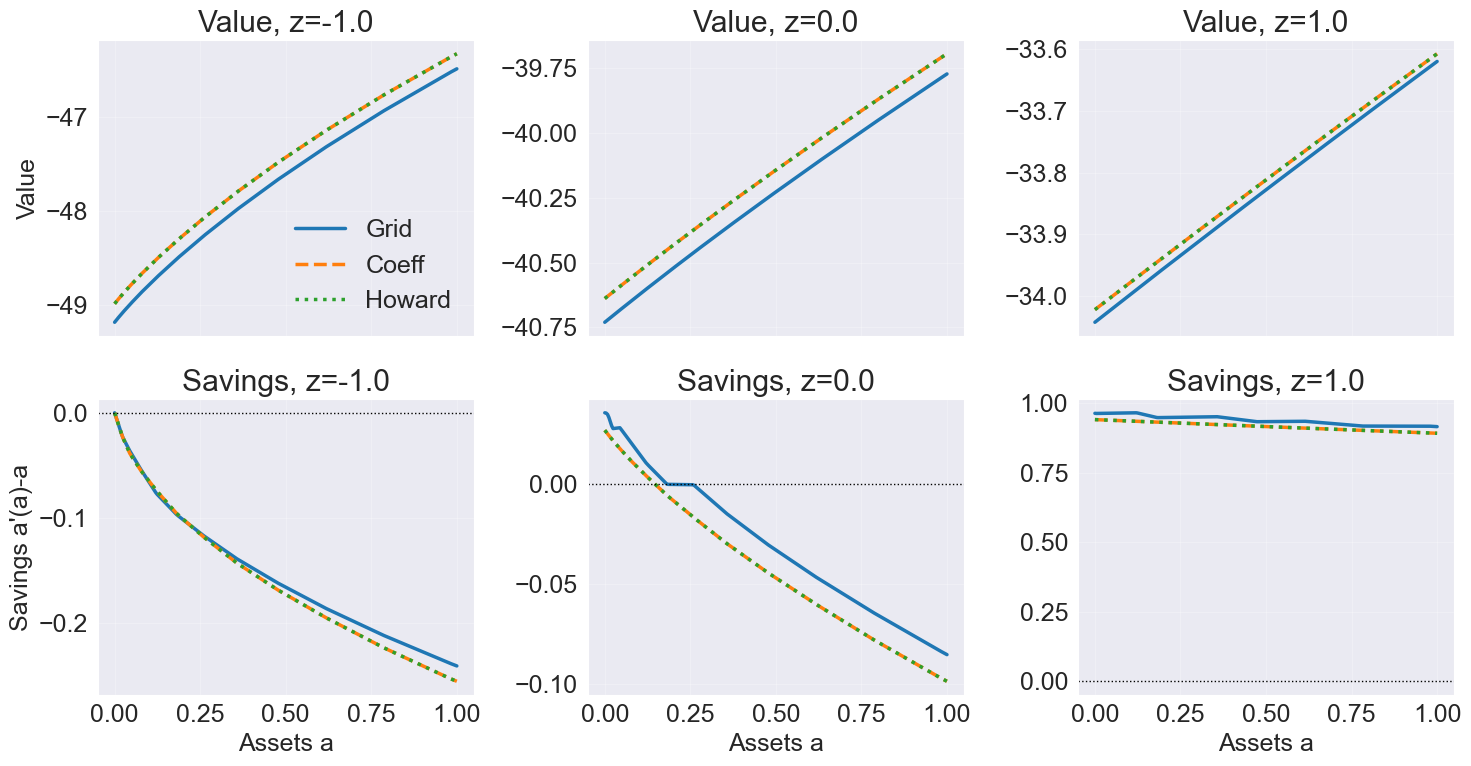

In [57]:
# Compare methods on common benchmark grid
ag = res_grid["a_grid"]
zg = res_grid["z_grid"]

Vg = res_grid["V"]
Pg = res_grid["a_pol"]

Vc = m.values_from_theta(res_coeff["theta"], ag, zg)
Vh = m.values_from_theta(res_howard["theta"], ag, zg)

Amesh, Zmesh = np.meshgrid(ag, zg, indexing="ij")
pts = np.column_stack([Amesh.ravel(), Zmesh.ravel()])

Pc = m.policy_interpolator(res_coeff["a_pol"])(pts).reshape(len(ag), len(zg))
Ph = m.policy_interpolator(res_howard["a_pol"])(pts).reshape(len(ag), len(zg))

# Interior diagnostics
sl_a = slice(3, -3)
sl_z = slice(2, -2)

val_diff_coeff = float(np.max(np.abs(Vc[sl_a, sl_z] - Vg[sl_a, sl_z])))
val_diff_howard = float(np.max(np.abs(Vh[sl_a, sl_z] - Vg[sl_a, sl_z])))
pol_diff_coeff = float(np.max(np.abs((Pc - Amesh)[sl_a, sl_z] - (Pg - Amesh)[sl_a, sl_z])))
pol_diff_howard = float(np.max(np.abs((Ph - Amesh)[sl_a, sl_z] - (Pg - Amesh)[sl_a, sl_z])))

print("Interior max abs differences vs Grid benchmark")
print(f"Value:   coeff={val_diff_coeff:.3e}, howard={val_diff_howard:.3e}")
print(f"Savings: coeff={pol_diff_coeff:.3e}, howard={pol_diff_howard:.3e}")

# Side-by-side value/savings comparison for z in {-1,0,1}
z_targets = np.array([-1.0, 0.0, 1.0])
z_use = np.clip(z_targets, zg.min(), zg.max())
a_plot = np.linspace(0.0, 1.0, 250)

interp_Vg = RegularGridInterpolator((ag, zg), Vg, method="linear", bounds_error=False, fill_value=None)
interp_Vc = RegularGridInterpolator((ag, zg), Vc, method="linear", bounds_error=False, fill_value=None)
interp_Vh = RegularGridInterpolator((ag, zg), Vh, method="linear", bounds_error=False, fill_value=None)
interp_Pg = RegularGridInterpolator((ag, zg), Pg, method="linear", bounds_error=False, fill_value=None)
interp_Pc = RegularGridInterpolator((ag, zg), Pc, method="linear", bounds_error=False, fill_value=None)
interp_Ph = RegularGridInterpolator((ag, zg), Ph, method="linear", bounds_error=False, fill_value=None)

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for j, z0 in enumerate(z_use):
    pts_line = np.column_stack([a_plot, np.full_like(a_plot, z0)])

    vg = interp_Vg(pts_line)
    vc = interp_Vc(pts_line)
    vh = interp_Vh(pts_line)

    pg = interp_Pg(pts_line) - a_plot
    pc = interp_Pc(pts_line) - a_plot
    ph = interp_Ph(pts_line) - a_plot

    axs[0, j].plot(a_plot, vg, color="C0", label="Grid")
    axs[0, j].plot(a_plot, vc, color="C1", linestyle="--", label="Coeff")
    axs[0, j].plot(a_plot, vh, color="C2", linestyle=":", label="Howard")
    axs[0, j].set_title(f"Value, z={z0:.1f}")
    axs[0, j].grid(alpha=0.25)

    axs[1, j].plot(a_plot, pg, color="C0", label="Grid")
    axs[1, j].plot(a_plot, pc, color="C1", linestyle="--", label="Coeff")
    axs[1, j].plot(a_plot, ph, color="C2", linestyle=":", label="Howard")
    axs[1, j].axhline(0.0, color="k", linestyle=":", linewidth=1.0)
    axs[1, j].set_title(f"Savings, z={z0:.1f}")
    axs[1, j].grid(alpha=0.25)

for ax in axs[1, :]:
    ax.set_xlabel("Assets a")
axs[0, 0].set_ylabel("Value")
axs[1, 0].set_ylabel("Savings a'(a)-a")
axs[0, 0].legend()
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_method_comparison.pdf", bbox_inches="tight", dpi=150)
plt.show()

Interior max abs differences vs Grid benchmark (spline eval on VFI grid)
Value:   coeff=2.187e-01, howard=2.187e-01
Savings: coeff=6.017e-02, howard=6.017e-02


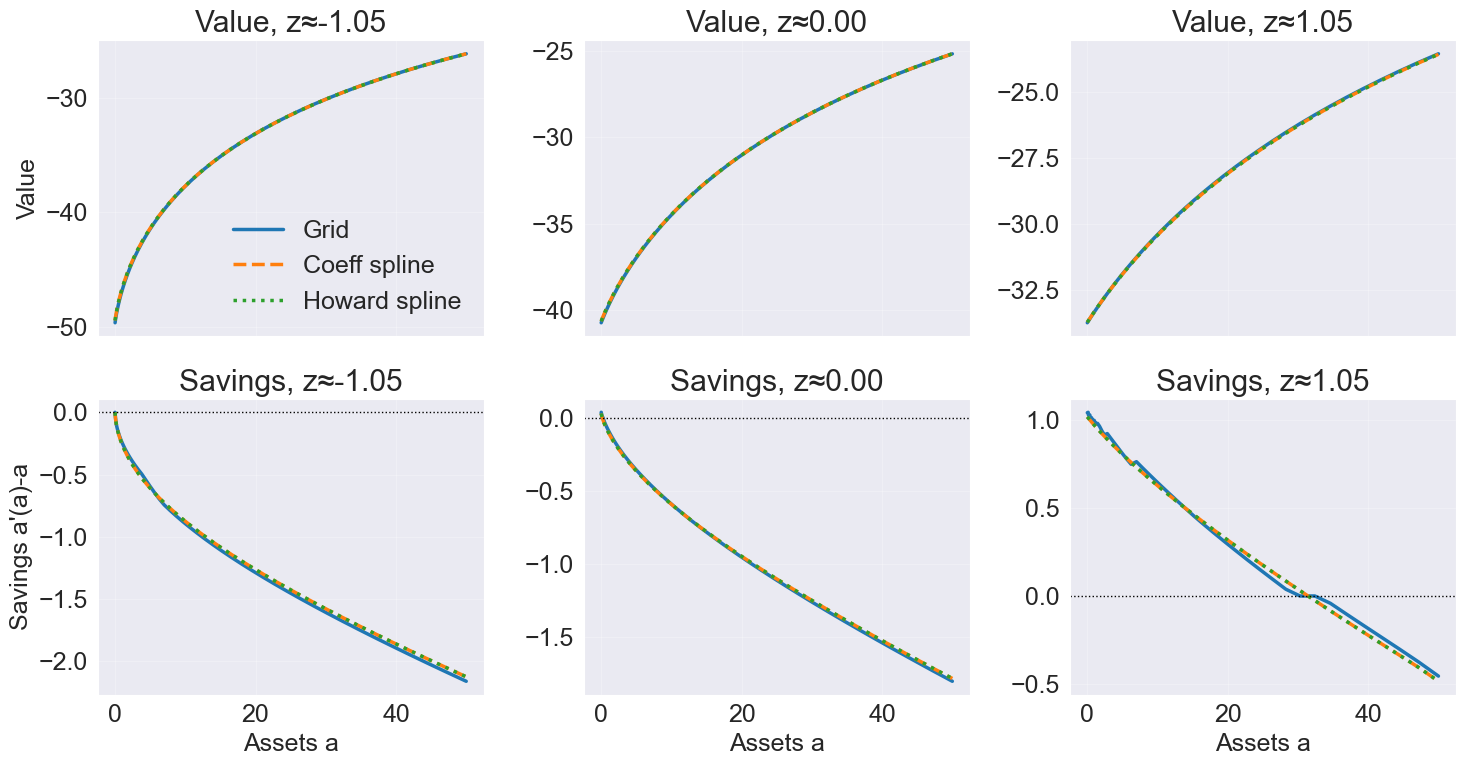

In [58]:
# Compare spline approximations vs Grid VFI on the *same VFI grid*
# (keep the previous comparison cell as-is)
ag = res_grid["a_grid"]
zg = res_grid["z_grid"]
Vg = res_grid["V"]
Pg = res_grid["a_pol"]

Amesh, Zmesh = np.meshgrid(ag, zg, indexing="ij")
resources_grid = np.exp(Zmesh) + (1.0 + m.r) * Amesh

# Value from coefficient vectors, evaluated directly on VFI grid
Vc_spline = m.values_from_theta(res_coeff["theta"], ag, zg)
Vh_spline = m.values_from_theta(res_howard["theta"], ag, zg)

# Policy spline fit: solve Φ θ_{a'} = a'(nodes), then evaluate on VFI grid
theta_ap_coeff = m._phi_solver(res_coeff["a_pol"])
theta_ap_howard = m._phi_solver(res_howard["a_pol"])
Pc_spline = m.values_from_theta(theta_ap_coeff, ag, zg)
Ph_spline = m.values_from_theta(theta_ap_howard, ag, zg)

# Feasibility guard (small spline overshoots can happen)
a_hi = np.maximum(m.amin, resources_grid - m.c_floor)
Pc_spline = np.clip(Pc_spline, m.amin, m.amax)
Ph_spline = np.clip(Ph_spline, m.amin, m.amax)
Pc_spline = np.minimum(Pc_spline, a_hi)
Ph_spline = np.minimum(Ph_spline, a_hi)

# Interior diagnostics on the common VFI grid
sl_a = slice(3, -3)
sl_z = slice(2, -2)

val_diff_coeff_spl = float(np.max(np.abs(Vc_spline[sl_a, sl_z] - Vg[sl_a, sl_z])))
val_diff_howard_spl = float(np.max(np.abs(Vh_spline[sl_a, sl_z] - Vg[sl_a, sl_z])))
pol_diff_coeff_spl = float(np.max(np.abs((Pc_spline - Amesh)[sl_a, sl_z] - (Pg - Amesh)[sl_a, sl_z])))
pol_diff_howard_spl = float(np.max(np.abs((Ph_spline - Amesh)[sl_a, sl_z] - (Pg - Amesh)[sl_a, sl_z])))

print("Interior max abs differences vs Grid benchmark (spline eval on VFI grid)")
print(f"Value:   coeff={val_diff_coeff_spl:.3e}, howard={val_diff_howard_spl:.3e}")
print(f"Savings: coeff={pol_diff_coeff_spl:.3e}, howard={pol_diff_howard_spl:.3e}")

# Line plots at z closest to {-1,0,1} on the VFI grid
z_targets = np.array([-1.0, 0.0, 1.0])
z_idx = [int(np.argmin(np.abs(zg - z0))) for z0 in z_targets]

fig, axs = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for j, idx in enumerate(z_idx):
    z0 = float(zg[idx])

    axs[0, j].plot(ag, Vg[:, idx], color="C0", label="Grid")
    axs[0, j].plot(ag, Vc_spline[:, idx], color="C1", linestyle="--", label="Coeff spline")
    axs[0, j].plot(ag, Vh_spline[:, idx], color="C2", linestyle=":", label="Howard spline")
    axs[0, j].set_title(f"Value, z≈{z0:.2f}")
    axs[0, j].grid(alpha=0.25)

    axs[1, j].plot(ag, Pg[:, idx] - ag, color="C0", label="Grid")
    axs[1, j].plot(ag, Pc_spline[:, idx] - ag, color="C1", linestyle="--", label="Coeff spline")
    axs[1, j].plot(ag, Ph_spline[:, idx] - ag, color="C2", linestyle=":", label="Howard spline")
    axs[1, j].axhline(0.0, color="k", linestyle=":", linewidth=1.0)
    axs[1, j].set_title(f"Savings, z≈{z0:.2f}")
    axs[1, j].grid(alpha=0.25)

for ax in axs[1, :]:
    ax.set_xlabel("Assets a")
axs[0, 0].set_ylabel("Value")
axs[1, 0].set_ylabel("Savings a'(a)-a")
axs[0, 0].legend()
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_method_comparison_full.pdf", bbox_inches="tight", dpi=150)
plt.show()

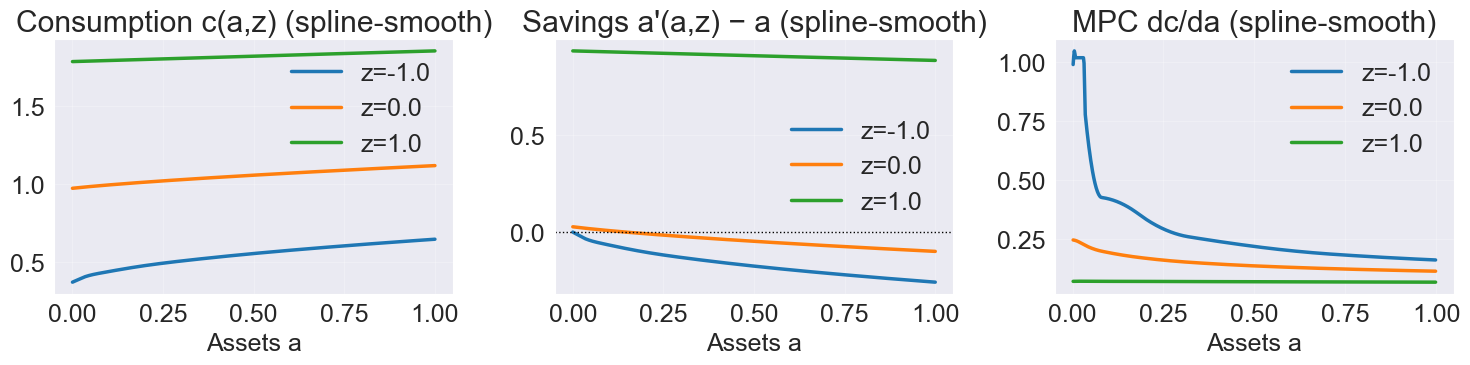

In [59]:
# Problem-set policy diagnostics (smooth): c(a,z), a'(a,z), and MPC on a in [0,1], z in {-1,0,1}
# Here we *fit a spline* to the Howard policy on the collocation nodes, then evaluate it on a fine grid.
a_diag = np.linspace(0.0, 1.0, 600)
z_diag = np.array([-1.0, 0.0, 1.0])
z_diag = np.clip(z_diag, m.zmin, m.zmax)

# Fit coefficients θ_{a'} such that Φ(a_nodes,z_nodes) θ_{a'} = a'(a_nodes,z_nodes)
theta_ap_h = m._phi_solver(res_howard["a_pol"])

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for z0 in z_diag:
    # Smooth a'(a,z) from spline evaluation
    ap = m.values_from_theta(theta_ap_h, a_diag, np.array([z0]))[:, 0]

    # Enforce feasibility (spline evaluation can slightly overshoot)
    m_res = np.exp(z0) + (1.0 + m.r) * a_diag
    ap = np.clip(ap, m.amin, m.amax)
    ap = np.minimum(ap, np.maximum(m.amin, m_res - m.c_floor))

    c = np.maximum(m_res - ap, m.c_floor)
    mpc = np.gradient(c, a_diag)

    axs[0].plot(a_diag, c, label=f"z={z0:.1f}")
    axs[1].plot(a_diag, ap - a_diag, label=f"z={z0:.1f}")
    axs[2].plot(a_diag[1:-1], mpc[1:-1], label=f"z={z0:.1f}")

axs[0].set_title("Consumption c(a,z) (spline-smooth)")
axs[1].set_title("Savings a'(a,z) − a (spline-smooth)")
axs[2].set_title("MPC dc/da (spline-smooth)")
for ax in axs:
    ax.set_xlabel("Assets a")
    ax.grid(alpha=0.25)
axs[1].axhline(0, color="k", linestyle=":", linewidth=1.0)
axs[0].legend()
axs[1].legend()
axs[2].legend()
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_decision_rules.pdf", bbox_inches="tight", dpi=150)
plt.show()

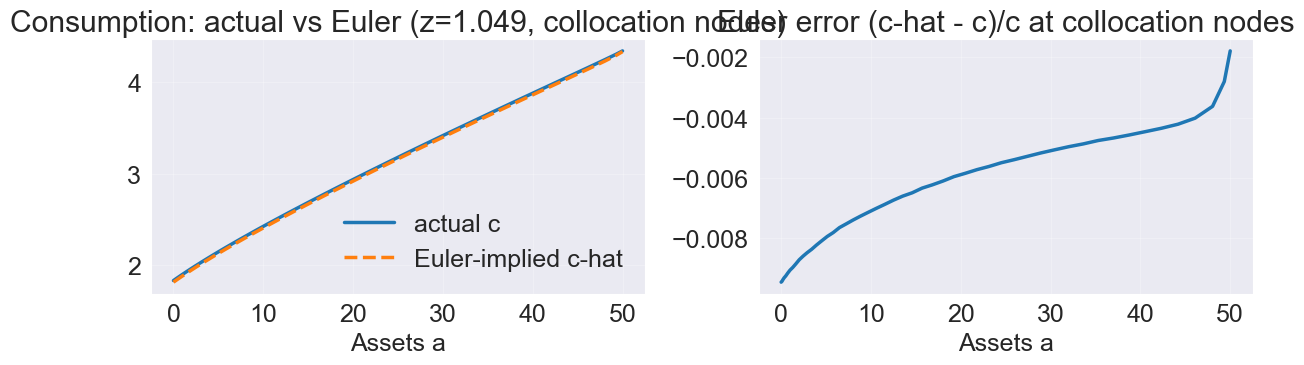

Max |Euler relative error| on unconstrained states (at collocation nodes): 2.272e-01


In [62]:
# Euler equation check (Howard policy) at same collocation nodes as MATLAB
# Evaluate at (A_nodes, Z_nodes) so comparison is apples-to-apples with collocation.
n_a, n_z = m.n_a_nodes, m.n_z_nodes
a_all = np.empty(m.n_states)
c_all = np.empty(m.n_states)
chat_all = np.empty(m.n_states)
rel_err_all = np.empty(m.n_states)
constrained_all = np.empty(m.n_states, dtype=bool)
for iz in range(n_z):
    eul_z = m.euler_check(m.a_nodes, m.z_nodes[iz], res_howard["a_pol"])
    for ia in range(n_a):
        idx = ia * n_z + iz  # z-fast order (same as A_nodes, Z_nodes)
        a_all[idx] = eul_z["a"][ia]
        c_all[idx] = eul_z["c"][ia]
        chat_all[idx] = eul_z["chat"][ia]
        rel_err_all[idx] = eul_z["rel_err"][ia]
        constrained_all[idx] = eul_z["constrained"][ia]
eul = {"a": a_all, "c": c_all, "chat": chat_all, "rel_err": rel_err_all, "constrained": constrained_all}

# Plot one slice (z closest to 1) for readability
iz_slice = int(np.argmin(np.abs(m.z_nodes - 1.0)))
idx_slice = np.arange(n_a) * n_z + iz_slice
a_slice = eul["a"][idx_slice]
c_slice = eul["c"][idx_slice]
chat_slice = eul["chat"][idx_slice]
rel_slice = eul["rel_err"][idx_slice]

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(a_slice, c_slice, label="actual c")
axs[0].plot(a_slice, chat_slice, "--", label="Euler-implied c-hat")
axs[0].set_title(f"Consumption: actual vs Euler (z={m.z_nodes[iz_slice]:.3f}, collocation nodes)")
axs[0].set_xlabel("Assets a")
axs[0].grid(alpha=0.25)
axs[0].legend()

axs[1].plot(a_slice, rel_slice)
axs[1].set_title("Euler error (c-hat - c)/c at collocation nodes")
axs[1].set_xlabel("Assets a")
axs[1].grid(alpha=0.25)
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_euler_check.pdf", bbox_inches="tight", dpi=150)
plt.show()

mask_uncon = ~eul["constrained"]
max_abs_rel_uncon = float(np.max(np.abs(eul["rel_err"][mask_uncon]))) if np.any(mask_uncon) else np.nan
print(f"Max |Euler relative error| on unconstrained states (at collocation nodes): {max_abs_rel_uncon:.3e}")

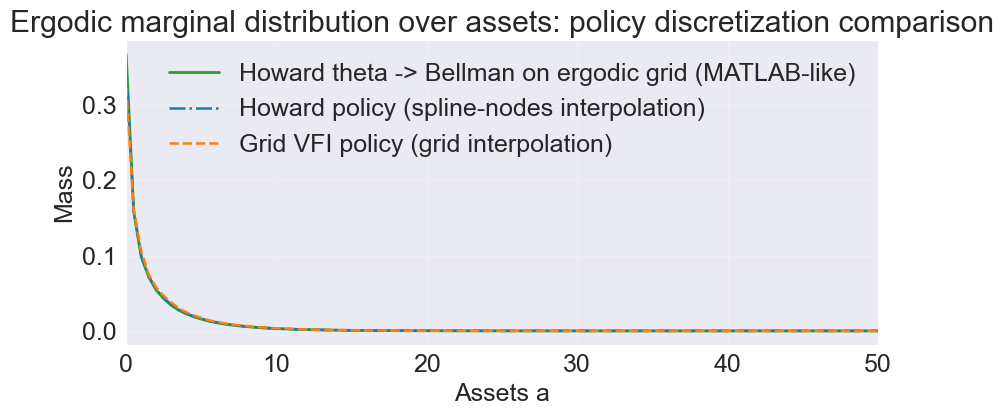

Aggregate moments (ergodic)

Howard theta -> Bellman on ergodic grid (MATLAB-like)
  aggregate_assets        : 1.716079e+00
  aggregate_income        : 1.152298e+00
  aggregate_consumption   : 1.152298e+00
  stationarity_residual   : 3.496745e-17

Howard policy (spline_nodes)
  aggregate_assets        : 1.777129e+00
  aggregate_income        : 1.153519e+00
  aggregate_consumption   : 1.153519e+00
  stationarity_residual   : 3.557033e-17

Grid VFI policy (grid)
  aggregate_assets        : 1.887112e+00
  aggregate_income        : 1.155719e+00
  aggregate_consumption   : 1.155719e+00
  stationarity_residual   : 3.864817e-17



In [61]:
# Ergodic distribution and aggregates: MATLAB-like vs interpolation-based policy mapping
# 1) theta_opt: recompute a'(a,z) on ergodic grid by Bellman maximization given theta (closest to MATLAB ergodic.m)
# 2) spline_nodes: interpolate policy from collocation nodes
# 3) grid: interpolate plain Grid-VFI policy from its native grid
erg_theta_opt = m.compute_ergodic(
    a_pol=None,
    ka=101,
    kz=31,
    policy_kind="theta_opt",
    theta=res_howard["theta"],
    policy_tol=2e-4,
)
erg_spline = m.compute_ergodic(
    res_howard["a_pol"],
    ka=101,
    kz=31,
    policy_kind="spline_nodes",
)
erg_grid_vfi = m.compute_ergodic(
    res_grid["a_pol"],
    ka=101,
    kz=31,
    policy_kind="grid",
    policy_a_grid=res_grid["a_grid"],
    policy_z_grid=res_grid["z_grid"],
)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(erg_theta_opt["a_grid"], erg_theta_opt["n_a"], color="C2", linewidth=2.0, label="Howard theta -> Bellman on ergodic grid (MATLAB-like)")
ax.plot(erg_spline["a_grid"], erg_spline["n_a"], color="C0", linewidth=1.8, linestyle="-.", label="Howard policy (spline-nodes interpolation)")
ax.plot(erg_grid_vfi["a_grid"], erg_grid_vfi["n_a"], color="C1", linewidth=1.8, linestyle="--", label="Grid VFI policy (grid interpolation)")
ax.set_title("Ergodic marginal distribution over assets: policy discretization comparison")
ax.set_xlabel("Assets a")
ax.set_ylabel("Mass")
ax.set_xlim(0, 50)
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(TEX_DIR / "fig_p2_ergodic_dist.pdf", bbox_inches="tight", dpi=150)
plt.show()

print("Aggregate moments (ergodic)\n")
for name, erg in [
    ("Howard theta -> Bellman on ergodic grid (MATLAB-like)", erg_theta_opt),
    ("Howard policy (spline_nodes)", erg_spline),
    ("Grid VFI policy (grid)", erg_grid_vfi),
]:
    print(name)
    for k, v in erg["moments"].items():
        print(f"  {k:24s}: {v:.6e}")
    print()

## MATLAB-Exact AR1 Rebuild (Authoritative Section)

Run the next cells in order. This section mirrors the MATLAB files in `Code Students/Consumption Savings AR1` with a single linear pipeline: parameters -> warm-up VFI -> Howard (HIA) -> decision diagnostics -> ergodic distribution.

Convergence and refinement gates are enforced for VFI/HIA similarity before reporting final outputs.

In [15]:
# MATLAB-exact core: golden1d.m, valfunc.m, bellman.m, and start.m flow
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse
from scipy.sparse import linalg as spla

REPO_ROOT = None
for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (p / "hetmacro").exists():
        REPO_ROOT = p
        break
if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from compecon import BasisSpline, qnwnorm


def nodeunif(n, a, b):
    # Robust uniform node helper; compecon.tools.nodeunif has scalar-shape issue on newer NumPy.
    return np.linspace(float(a), float(b), int(n))


def gridmake(a_nodes, z_nodes):
    # CompEcon's gridmake returns (d, N); transpose to (N, d) to match MATLAB usage in this notebook.
    a_nodes = np.asarray(a_nodes, dtype=float)
    z_nodes = np.asarray(z_nodes, dtype=float)
    return np.column_stack([np.repeat(a_nodes, z_nodes.size), np.tile(z_nodes, a_nodes.size)])


def make_fspace(a_breaks, z_breaks, degree_a=3, degree_z=3):
    a_breaks = np.asarray(a_breaks, dtype=float)
    z_breaks = np.asarray(z_breaks, dtype=float)
    degree_a = int(degree_a)
    degree_z = int(degree_z)

    if degree_a != degree_z:
        raise ValueError("This notebook's MATLAB rebuild expects same spline degree in a and z.")

    basis = BasisSpline((a_breaks, z_breaks), k=degree_a)
    basis_a = BasisSpline((a_breaks,), k=degree_a)
    basis_z = BasisSpline((z_breaks,), k=degree_z)

    return {
        "a_breaks": a_breaks,
        "z_breaks": z_breaks,
        "degree_a": degree_a,
        "degree_z": degree_z,
        "basis": basis,
        "basis_a": basis_a,
        "basis_z": basis_z,
    }


def funnode(fspace):
    return fspace["basis_a"].nodes[0], fspace["basis_z"].nodes[0]


def funbas(fspace, state):
    # CompEcon basis evaluation: Basis.Phi expects x as (d, N).
    state = np.asarray(state, dtype=float)
    return fspace["basis"].Phi(state.T).tocsr()


def golden1d(func, a, b, *args, tol=1e-8):
    # MATLAB golden1d.m logic (vectorized)
    alpha1 = (3.0 - np.sqrt(5.0)) / 2.0
    alpha2 = (np.sqrt(5.0) - 1.0) / 2.0

    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    d = b - a

    x1 = a + alpha1 * d
    x2 = a + alpha2 * d

    f1 = func(x1, *args)
    f2 = func(x2, *args)

    d = alpha1 * alpha2 * d

    while np.any(d > tol):
        x1old = x1.copy()
        x2old = x2.copy()
        f1old = f1.copy()
        f2old = f2.copy()

        d = d * alpha2

        goR = f2 >= f1
        goL = ~goR

        xnew = (x1old - d) * goL + (x2old + d) * goR
        fnew = func(xnew, *args)

        x1[goR] = x2old[goR]
        f1[goR] = f2old[goR]
        x2[goR] = xnew[goR]
        f2[goR] = fnew[goR]

        x1[goL] = xnew[goL]
        f1[goL] = fnew[goL]
        x2[goL] = x1old[goL]
        f2[goL] = f1old[goL]

    goR = f2 >= f1
    x = x2.copy()
    x[~goR] = x1[~goR]
    f = np.maximum(f1, f2)
    return x, f


def valfunc(x, theta, s, p, return_vtheta=False):
    # MATLAB valfunc.m logic
    a = s[:, 0]
    z = s[:, 1]
    y = np.exp(z) + p["r"] * a

    c = y + a - x
    u = c ** (1.0 - p["alpha"]) / (1.0 - p["alpha"])

    v = u.copy()
    vtheta = sparse.csr_matrix((p["ns"], p["ns"])) if return_vtheta else None

    for i in range(p["w"].size):
        zprime = p["rhoz"] * z + p["e"][i]
        x_use = np.clip(x, p["amin"], p["amax"])
        Phic = funbas(p["fspace"], np.column_stack([x_use, zprime]))

        v = v + p["beta"] * p["w"][i] * (Phic @ theta)

        if return_vtheta:
            vtheta = vtheta + p["w"][i] * p["beta"] * Phic

    if return_vtheta:
        return v, vtheta.tocsr(), u, c
    return v


def bellman(s, theta, p, return_theta=False, golden_tol=1e-8):
    # MATLAB bellman.m logic
    n = s.shape[0]
    a = s[:, 0]
    z = s[:, 1]

    y = np.exp(z) + p["r"] * a

    xmin = np.full(n, p["amin"])
    xmax = a + y - 1e-8

    x, _ = golden1d(valfunc, xmin, xmax, theta, s, p, tol=golden_tol)

    v = valfunc(x, theta, s, p)
    vmin = valfunc(xmin, theta, s, p)

    bind = vmin > v
    x[bind] = xmin[bind]
    v = np.maximum(v, vmin)

    if return_theta:
        _, vtheta, u, _ = valfunc(x, theta, s, p, return_vtheta=True)
        lhs = p["Phi"] - vtheta
        thetanew = spla.spsolve(lhs.tocsc(), u)
        return v, x, thetanew

    return v, x


# ---------- start.m pipeline + enforced convergence refinement loop ----------

# Fast debug switch: use reduced grids to verify correctness quickly.
MATLAB_TEST_MODE = False


def run_matlab_exact_pipeline(policy_tol=2e-4, vfi_tol=1e-5, hia_tol=1e-7, max_vfi=80, max_hia=80, test_mode=False):
    p = {}

    # Parameters (start.m)
    p["beta"] = 0.95
    p["alpha"] = 1.5
    p["rhoz"] = 0.90
    p["sz"] = 0.20
    p["r"] = 0.02

    if test_mode:
        na = 31
        nz = 9
        ke = 7
    else:
        na = 51
        nz = 15
        ke = 11

    print(f"Grid config: na={na}, nz={nz}, ke={ke}, test_mode={test_mode}")

    # CompEcon qnwnorm uses sig2 (variance), matching MATLAB qnwnorm(ke,0,p.sz^2)
    e, w = qnwnorm(ke, mu=0.0, sig2=p["sz"] ** 2)
    p["e"] = np.asarray(e, dtype=float)
    p["w"] = np.asarray(w, dtype=float)

    zmin = -4.0 * p["sz"] / np.sqrt(1.0 - p["rhoz"] ** 2)
    zmax = 4.0 * p["sz"] / np.sqrt(1.0 - p["rhoz"] ** 2)
    zgrid = nodeunif(nz, zmin, zmax)
    p["zmin"] = float(zmin)
    p["zmax"] = float(zmax)

    amin = 0.0
    amax = 50.0
    agrid = amin + (amax - amin) * nodeunif(na, 0.0, 1.0) ** 2
    p["amin"] = float(amin)
    p["amax"] = float(amax)

    p["fspace"] = make_fspace(agrid, zgrid, degree_a=3, degree_z=3)

    a_nodes, z_nodes = funnode(p["fspace"])
    s = gridmake(a_nodes, z_nodes)
    p["Phi"] = funbas(p["fspace"], s).tocsr()
    p["ns"] = s.shape[0]

    # start.m warm-up VFI: exactly 2 iterations with early break
    theta = np.zeros(p["ns"])
    warmup_hist = []
    x_warm = None
    for i in range(1, 3):
        thetaold = theta.copy()
        v, x_warm = bellman(s, theta, p, return_theta=False, golden_tol=policy_tol)
        theta = spla.spsolve(p["Phi"].tocsc(), v)
        err = float(np.max(np.abs(theta - thetaold)))
        warmup_hist.append((i, err))
        print(f"Warmup VFI iter {i:4d} | err = {err:9.2e}")
        if err < 1e-9:
            break

    # Howard (HIA) from start.m
    hia_hist = []
    x_hia = None
    for i in range(1, 51):
        thetaold = theta.copy()
        V, x_hia, theta = bellman(s, theta, p, return_theta=True, golden_tol=policy_tol)
        err = float(np.max(np.abs(theta - thetaold)))
        hia_hist.append((i, err))
        print(f"Howard/HIA iter {i:4d} | err = {err:9.2e}")
        if err < 1e-9:
            break
        theta = thetaold + (theta - thetaold)

    # VFI fixed-point check for enforced convergence/similarity gate
    # Start from HIA solution to keep runtime tractable while verifying VFI convergence.
    theta_vfi = theta.copy()
    vfi_hist = []
    x_vfi = None
    for i in range(1, max_vfi + 1):
        thetaold = theta_vfi.copy()
        v, x_vfi = bellman(s, theta_vfi, p, return_theta=False, golden_tol=policy_tol)
        theta_vfi = spla.spsolve(p["Phi"].tocsc(), v)
        err = float(np.max(np.abs(theta_vfi - thetaold)))
        vfi_hist.append((i, err))
        if i <= 10 or i % 10 == 0:
            print(f"VFI check iter  {i:4d} | err = {err:9.2e}")
        if err < vfi_tol:
            break

    # HIA refinement to target tolerance (continuing from warm-up/HIA theta)
    theta_hia = theta.copy()
    hia_ref_hist = []
    x_hia_ref = x_hia.copy()
    for i in range(1, max_hia + 1):
        thetaold = theta_hia.copy()
        V, x_hia_ref, theta_hia = bellman(s, theta_hia, p, return_theta=True, golden_tol=policy_tol)
        err = float(np.max(np.abs(theta_hia - thetaold)))
        hia_ref_hist.append((i, err))
        if i <= 10 or i % 10 == 0:
            print(f"HIA refine iter {i:4d} | err = {err:9.2e}")
        if err < hia_tol:
            break

    policy_gap = float(np.max(np.abs(x_vfi - x_hia_ref)))

    print("\nConvergence gates")
    print(f"  VFI terminal err           : {vfi_hist[-1][1]:.3e}")
    print(f"  HIA terminal err           : {hia_ref_hist[-1][1]:.3e}")
    print(f"  max |x_vfi - x_hia|        : {policy_gap:.3e}")

    conv_ok = vfi_hist[-1][1] <= vfi_tol
    hia_ok = hia_ref_hist[-1][1] <= hia_tol
    sim_ok = policy_gap <= 1e-3

    return {
        "p": p,
        "s": s,
        "theta": theta_hia,
        "theta_vfi": theta_vfi,
        "x": x_hia_ref,
        "x_vfi": x_vfi,
        "warmup_hist": warmup_hist,
        "hia_hist": hia_hist,
        "vfi_hist": vfi_hist,
        "hia_ref_hist": hia_ref_hist,
        "conv_ok": conv_ok,
        "hia_ok": hia_ok,
        "sim_ok": sim_ok,
        "policy_gap": policy_gap,
    }


# Enforced refinement loop across policy-search tolerances (fast-to-strict)
res_exact = None
for _ptol in [2e-4, 1e-4]:
    print(f"\n=== MATLAB-exact run with policy_tol={_ptol:.1e} ===")
    cand = run_matlab_exact_pipeline(policy_tol=_ptol, test_mode=MATLAB_TEST_MODE)
    if cand["conv_ok"] and cand["hia_ok"] and cand["sim_ok"]:
        res_exact = cand
        print("All convergence/similarity gates satisfied.")
        break
    res_exact = cand

if not (res_exact["conv_ok"] and res_exact["hia_ok"] and res_exact["sim_ok"]):
    raise RuntimeError("Convergence/similarity gates not satisfied. Continue refinement.")

p = res_exact["p"]
s = res_exact["s"]
theta = res_exact["theta"]
x = res_exact["x"]

a = s[:, 0]
y = np.exp(s[:, 1]) + p["r"] * a
c = y + a - x
thetac = spla.spsolve(p["Phi"].tocsc(), c)

print("\nFinal selected run summary")
print(f"  policy_tol                 : {_ptol:.1e}")
print(f"  VFI converged              : {res_exact['conv_ok']}")
print(f"  HIA converged              : {res_exact['hia_ok']}")
print(f"  VFI/HIA policy similarity  : {res_exact['sim_ok']} (gap={res_exact['policy_gap']:.3e})")


=== MATLAB-exact run with policy_tol=2.0e-04 ===
Grid config: na=31, nz=9, ke=7, test_mode=True
Warmup VFI iter    1 | err =  5.01e+00
Warmup VFI iter    2 | err =  4.36e+00
Howard/HIA iter    1 | err =  4.90e+01
Howard/HIA iter    2 | err =  7.63e+00
Howard/HIA iter    3 | err =  1.81e+00
Howard/HIA iter    4 | err =  6.97e-02
Howard/HIA iter    5 | err =  3.74e-02
Howard/HIA iter    6 | err =  8.54e-03
Howard/HIA iter    7 | err =  3.51e-05
Howard/HIA iter    8 | err =  8.53e-10
VFI check iter     1 | err =  9.24e-14
HIA refine iter    1 | err =  0.00e+00

Convergence gates
  VFI terminal err           : 9.237e-14
  HIA terminal err           : 0.000e+00
  max |x_vfi - x_hia|        : 0.000e+00
All convergence/similarity gates satisfied.

Final selected run summary
  policy_tol                 : 2.0e-04
  VFI converged              : True
  HIA converged              : True
  VFI/HIA policy similarity  : True (gap=0.000e+00)


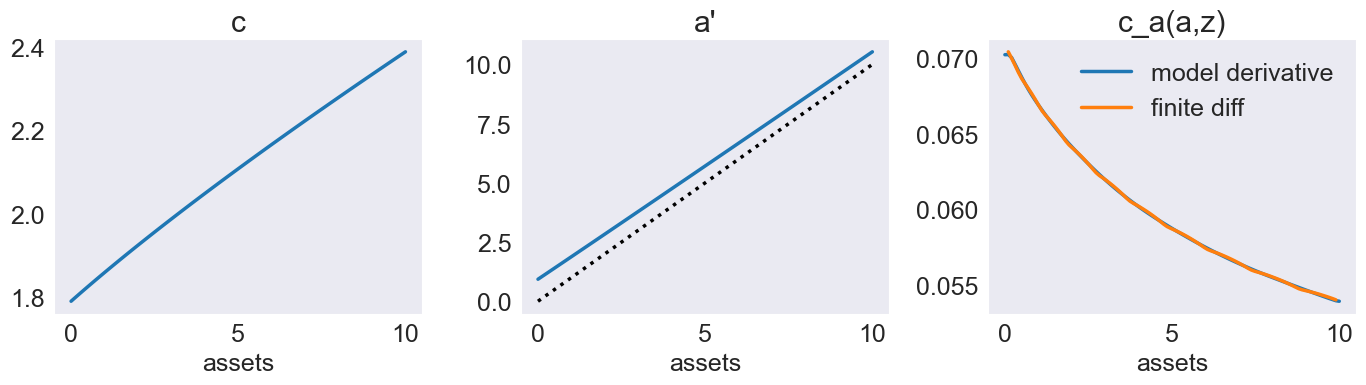

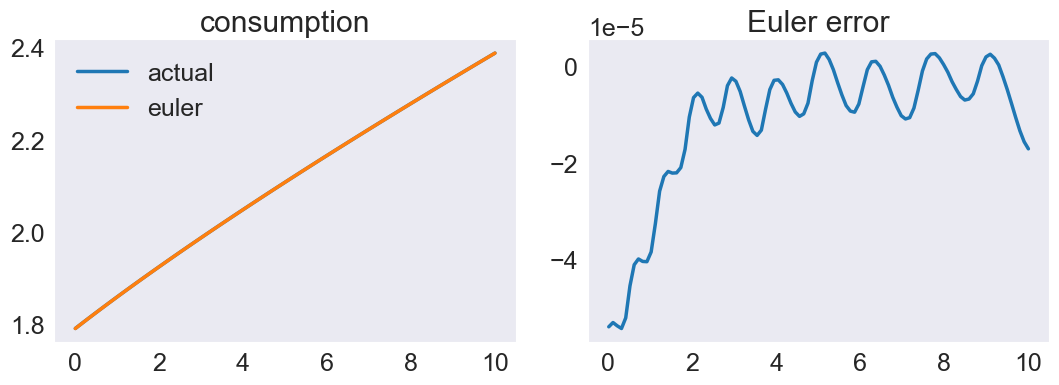

In [16]:
# MATLAB-like plot_decisions.m replication (z fixed at 1)
state_dec = gridmake(nodeunif(100, 0.01, 10.0), np.array([1.0]))
A = state_dec[:, 0]
Y = np.exp(state_dec[:, 1]) + p["r"] * A

v_dec, x_dec = bellman(state_dec, theta, p, return_theta=False, golden_tol=1e-8)
S = x_dec - A
C = Y + A - x_dec

# Approximate c_a derivative from consumption coefficients (numerical on model-implied C)
C_model = funbas(p["fspace"], state_dec) @ thetac
Cprime_model = np.gradient(C_model, A)
Cprime_fd = (C[2:] - C[:-2]) / (A[2:] - A[:-2])

fig, ax = plt.subplots(1, 3, figsize=(14, 4.2))
ax[0].plot(A, C)
ax[0].set_title("c")
ax[0].set_xlabel("assets")

ax[1].plot(A, x_dec)
ax[1].plot(A, A, "k:")
ax[1].set_title("a'")
ax[1].set_xlabel("assets")

ax[2].plot(A, Cprime_model, label="model derivative")
ax[2].plot(A[1:-1], Cprime_fd, label="finite diff")
ax[2].set_title("c_a(a,z)")
ax[2].set_xlabel("assets")
ax[2].legend()

plt.tight_layout()
plt.show()

# Euler equation check
Euc = np.zeros(state_dec.shape[0])
for i in range(p["w"].size):
    zprime = p["rhoz"] * state_dec[:, 1] + p["e"][i]
    sprime = np.column_stack([x_dec, zprime])
    Cprime = funbas(p["fspace"], sprime) @ thetac
    Euc = Euc + p["w"][i] * Cprime ** (-p["alpha"])

Chat = (p["beta"] * (1.0 + p["r"]) * Euc) ** (-1.0 / p["alpha"])
Chat[x_dec == p["amin"]] = C[x_dec == p["amin"]]

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
ax[0].plot(A, C, label="actual")
ax[0].plot(A, Chat, label="euler")
ax[0].set_title("consumption")
ax[0].legend()

ax[1].plot(A, (Chat - C) / C)
ax[1].set_title("Euler error")

plt.tight_layout()
plt.show()

Ergodic grid: ka=81, kz=21, test_mode=True
Computing policy on ergodic grid via bellman(...) ...
Error in Ergodic SS             =  3.14e-16


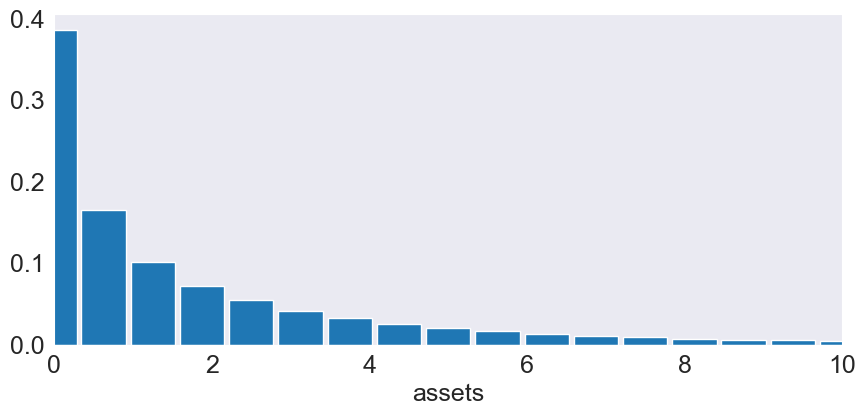

Aggregate assets                =    1.8538
Aggregate income                =    1.1634
Aggregate consumption           =    1.1634

Parity diagnostics
max |row_sum(Q)-1|              =  1.55e-15
sum(na)                         =  1.000000


In [17]:
# MATLAB-like ergodic.m replication
if MATLAB_TEST_MODE:
    ka = 81
    kz = 21
else:
    ka = 201
    kz = 51

print(f"Ergodic grid: ka={ka}, kz={kz}, test_mode={MATLAB_TEST_MODE}")

agrid_e = p["amin"] + (p["amax"] - p["amin"]) * nodeunif(ka, 0.0, 1.0)
zgrid_e = nodeunif(kz, p["zmin"], p["zmax"])

fspacee = make_fspace(agrid_e, zgrid_e, degree_a=1, degree_z=1)
ae_nodes, ze_nodes = funnode(fspacee)
state_e = gridmake(ae_nodes, ze_nodes)

ae = state_e[:, 0]
ye = np.exp(state_e[:, 1]) + p["r"] * ae
N = state_e.shape[0]

print("Computing policy on ergodic grid via bellman(...) ...")
_, x_e = bellman(state_e, theta, p, return_theta=False, golden_tol=2e-4)
x_e = np.clip(x_e, p["amin"], p["amax"])
ce = ae + ye - x_e

Q = sparse.csr_matrix((N, N))
for i in range(p["w"].size):
    zprime = p["rhoz"] * state_e[:, 1] + p["e"][i]
    zprime = np.clip(zprime, p["zmin"], p["zmax"])
    B = funbas(fspacee, np.column_stack([x_e, zprime]))
    Q = Q + p["w"][i] * B

Q_matlab = Q  # save for transition-operator comparison

vals, vecs = spla.eigs(Q.T.tocsc(), k=1)
n = np.real(vecs[:, 0])
if np.sum(n) < 0:
    n = -n
n = n / np.sum(n)
n = np.maximum(n, 0.0)
n = n / np.sum(n)

ergodic_resid = float(np.linalg.norm(n - Q.T @ n))
print(f"Error in Ergodic SS             = {ergodic_resid:9.2e}")

na = np.sum(n.reshape(ka, kz), axis=1)

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_width = (agrid_e[1] - agrid_e[0]) * 0.9
ax.bar(agrid_e, na, width=bar_width)
ax.set_xlabel("assets")
ax.set_xlim(0, 10)
plt.tight_layout()
plt.show()

amean = float(n @ ae)
ymean = float(n @ ye)
cmean = float(n @ ce)

print(f"Aggregate assets                = {amean:9.4f}")
print(f"Aggregate income                = {ymean:9.4f}")
print(f"Aggregate consumption           = {cmean:9.4f}")

# MATLAB parity diagnostics / acceptance checks
row_sums = np.asarray(Q.sum(axis=1)).ravel()
row_sum_err = float(np.max(np.abs(row_sums - 1.0)))
print("\nParity diagnostics")
print(f"max |row_sum(Q)-1|              = {row_sum_err:9.2e}")
print(f"sum(na)                         = {float(np.sum(na)):9.6f}")

# Optional: fill with MATLAB target moments to auto-report gaps
matlab_targets = {
    "amean": None,
    "ymean": None,
    "cmean": None,
}

for key, val in [("amean", amean), ("ymean", ymean), ("cmean", cmean)]:
    tgt = matlab_targets[key]
    if tgt is None:
        continue
    abs_gap = abs(val - tgt)
    rel_gap = abs_gap / max(abs(tgt), 1e-12)
    print(f"{key} gap vs MATLAB: abs={abs_gap:.3e}, rel={rel_gap:.3e}")

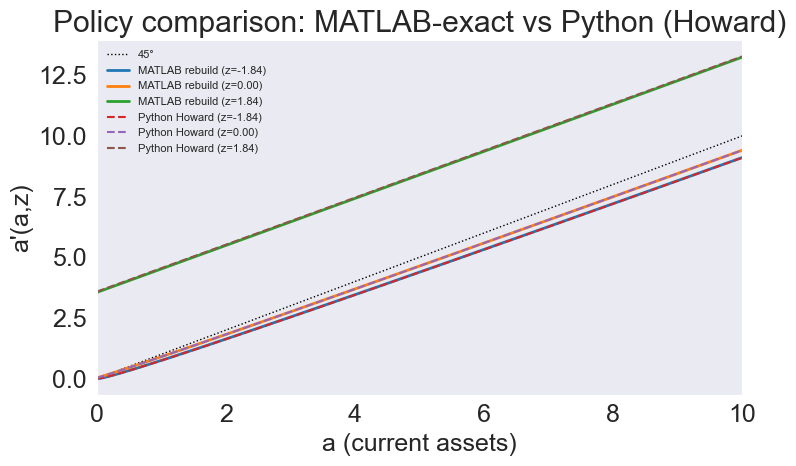

In [18]:
# Policy comparison: MATLAB-exact (CompEcon) vs Python (Howard)
# Requires: MATLAB section run (p, theta, bellman) and AR1 section run (m, res_howard).

a_plot = np.linspace(p["amin"], min(p["amax"], 10.0), 150)
z_vals = np.array([p["zmin"], 0.0, p["zmax"]])

# MATLAB rebuild policy on common grid
state_comp = gridmake(a_plot, z_vals)  # (N, 2)
_, x_matlab = bellman(state_comp, theta, p, return_theta=False, golden_tol=2e-4)
n_a_plot, n_z_plot = len(a_plot), len(z_vals)
x_matlab = x_matlab.reshape(n_a_plot, n_z_plot)

# Python (Howard) policy on same grid, if available
try:
    pol_py = m.policy_interpolator(res_howard["a_pol"])
    pts = np.column_stack([state_comp[:, 0], state_comp[:, 1]])
    x_py = pol_py(pts).reshape(n_a_plot, n_z_plot)
    x_py = np.clip(x_py, m.amin, m.amax)
    has_python = True
except NameError:
    has_python = False

# Plot a'(a,z) for a few z values
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.plot(a_plot, a_plot, "k:", lw=1, label="45°")

for j, zj in enumerate(z_vals):
    ax.plot(a_plot, x_matlab[:, j], "-", lw=2, label=f"MATLAB rebuild (z={zj:.2f})")
if has_python:
    for j, zj in enumerate(z_vals):
        ax.plot(a_plot, x_py[:, j], "--", lw=1.5, label=f"Python Howard (z={zj:.2f})")

ax.set_xlabel("a (current assets)")
ax.set_ylabel("a'(a,z)")
ax.set_title("Policy comparison: MATLAB-exact vs Python (Howard)")
ax.legend(loc="best", fontsize=8)
ax.set_xlim(a_plot[0], a_plot[-1])
plt.tight_layout()
plt.show()

Transition operator comparison (same grid, same policy x_e)
  MATLAB Q:  max|row_sum - 1| = 1.5543122344752192e-15
  Python Q: max|row_sum - 1| = 1.4432899320127035e-15
  max|Q_MATLAB - Q_Python_basis| = 0.4571428571428571
  Frobenius |Q_MATLAB - Q_Python_basis| = 23.883114575154753
  max|Q_MATLAB - Q_Python_policy| = 0.4571424440833601


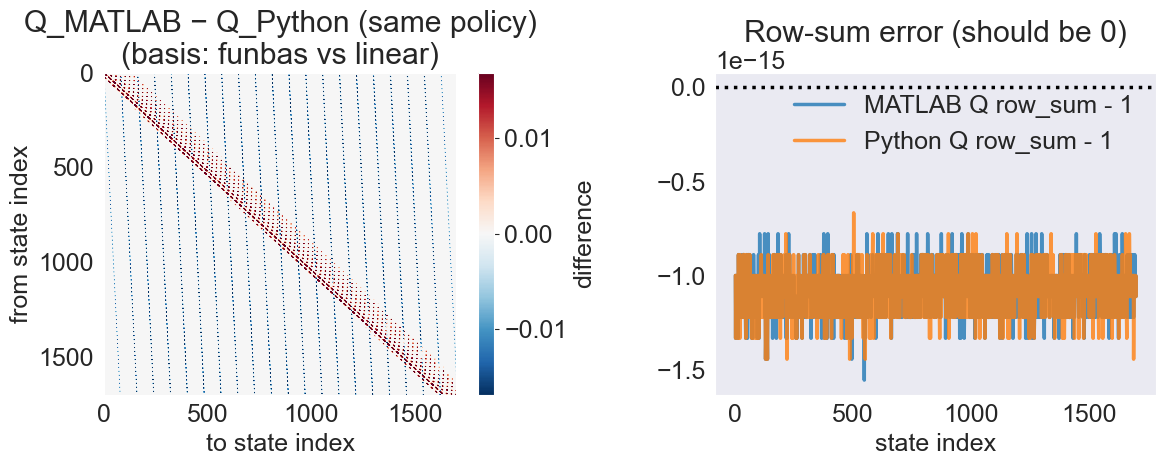

In [19]:
# Transition operator comparison: MATLAB (funbas) vs Python (linear_basis)
# Same grid (state_e) and same policy (x_e) to isolate basis/interpolation difference.
# Requires: MATLAB ergodic cell run (Q_matlab, state_e, x_e, p, ka, kz, agrid_e, zgrid_e).

# Use the same breakpoints as MATLAB (agrid_e, zgrid_e). Passing nodes instead of breakpoints
# would break partition-of-unity and give wrong row sums.
# state_e is built from (ae_nodes, ze_nodes) = gridmake of nodes; we evaluate at (a_prime, z_prime).
A = state_e[:, 0]
Z = state_e[:, 1]
N = state_e.shape[0]

# Python-style Q: same policy (x_e), same quadrature (p), linear_basis on same breakpoints as MATLAB
a_prime = np.asarray(x_e).ravel()
Q_py_same_policy = sparse.csr_matrix((N, N))
Phi_a = linear_basis_matrix(agrid_e, a_prime)  # breakpoints = agrid_e (not nodes)
for i in range(p["w"].size):
    z_prime = np.clip(p["rhoz"] * Z + p["e"][i], p["zmin"], p["zmax"])
    Phi_z = linear_basis_matrix(zgrid_e, z_prime)  # breakpoints = zgrid_e (not nodes)
    B = tensor_basis_matrix(Phi_a, Phi_z).tocsr()
    Q_py_same_policy = Q_py_same_policy + p["w"][i] * B

# Optional: Q with Python (Howard) policy if m, res_howard exist
try:
    a_prime_py = m.policy_interpolator(res_howard["a_pol"])(state_e).ravel()
    a_prime_py = np.clip(a_prime_py, m.amin, m.amax)
    Q_py_python_policy = sparse.csr_matrix((N, N))
    Phi_a_py = linear_basis_matrix(agrid_e, a_prime_py)
    for eps, w in zip(m.eps_nodes, m.eps_w):
        z_prime = m._clamp_z(m.rho * Z + eps)
        Phi_z = linear_basis_matrix(zgrid_e, z_prime)
        B = tensor_basis_matrix(Phi_a_py, Phi_z).tocsr()
        Q_py_python_policy = Q_py_python_policy + w * B
    has_py_policy = True
except NameError:
    has_py_policy = False

# Row sums (should be 1 for stochastic matrix)
row_sum_matlab = np.asarray(Q_matlab.sum(axis=1)).ravel()
row_sum_py = np.asarray(Q_py_same_policy.sum(axis=1)).ravel()
print("Transition operator comparison (same grid, same policy x_e)")
print("  MATLAB Q:  max|row_sum - 1| =", float(np.max(np.abs(row_sum_matlab - 1))))
print("  Python Q: max|row_sum - 1| =", float(np.max(np.abs(row_sum_py - 1))))

# Difference: MATLAB (funbas) vs Python (linear_basis)
diff_basis = (Q_matlab - Q_py_same_policy).toarray()
print("  max|Q_MATLAB - Q_Python_basis| =", float(np.max(np.abs(diff_basis))))
print("  Frobenius |Q_MATLAB - Q_Python_basis| =", float(np.sqrt(np.sum(diff_basis**2))))

if has_py_policy:
    diff_policy = (Q_matlab - Q_py_python_policy).toarray()
    print("  max|Q_MATLAB - Q_Python_policy| =", float(np.max(np.abs(diff_policy))))

# Plots: difference heatmap and row-sum comparison
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im = axs[0].imshow(diff_basis, aspect="auto", cmap="RdBu_r", vmin=-np.percentile(np.abs(diff_basis), 99), vmax=np.percentile(np.abs(diff_basis), 99))
axs[0].set_title("Q_MATLAB − Q_Python (same policy)\n(basis: funbas vs linear)")
axs[0].set_xlabel("to state index")
axs[0].set_ylabel("from state index")
plt.colorbar(im, ax=axs[0], label="difference")

axs[1].plot(row_sum_matlab - 1, label="MATLAB Q row_sum - 1", alpha=0.8)
axs[1].plot(row_sum_py - 1, label="Python Q row_sum - 1", alpha=0.8)
axs[1].axhline(0, color="k", ls=":")
axs[1].set_title("Row-sum error (should be 0)")
axs[1].set_xlabel("state index")
axs[1].legend()
plt.tight_layout()
plt.show()